# Chapitre 4 — EDA diagnostique et qualité des données

**Durée estimée : 8-10 heures**

---

## Objectifs d'apprentissage

À la fin de ce chapitre, vous serez capable de :

1. **Distinguer** l'EDA diagnostique (trouver les problèmes) de l'EDA analytique (comprendre les patterns)
2. **Évaluer** la qualité des données selon les 6 dimensions standardisées
3. **Détecter** les valeurs manquantes, doublons et outliers avec les outils pandas appropriés
4. **Documenter** les problèmes identifiés dans une checklist de qualité priorisée

---

## 4.4 Détection des valeurs manquantes

### Comprendre les patterns de missing

Les valeurs manquantes ne sont pas toutes égales. Il existe trois types :

| Type | Définition | Exemple |
|------|------------|--------|
| **MCAR** (Missing Completely At Random) | Manque aléatoire, aucun pattern | Erreur de saisie ponctuelle |
| **MAR** (Missing At Random) | Manque lié à d'autres variables | Revenus manquants surtout chez les jeunes |
| **MNAR** (Missing Not At Random) | Manque lié à la valeur elle-même | Revenus élevés non déclarés volontairement |

**Pourquoi c'est important ?** Le type de missing influence la stratégie de traitement (Chapitre 5).

### Quantifier les valeurs manquantes

In [13]:
# Créer un DataFrame avec des missing
np.random.seed(42)
df_missing = pd.DataFrame({
    'A': [1, 2, np.nan, 4, 5, np.nan, 7, 8, 9, 10],
    'B': [np.nan, 2, 3, np.nan, 5, 6, np.nan, 8, np.nan, 10],
    'C': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
})

print("DataFrame avec valeurs manquantes :")
df_missing

DataFrame avec valeurs manquantes :


,A,B,C
0,1.0,NaN,1
1,2.0,2.0,2
2,NaN,3.0,3
3,4.0,NaN,4
4,5.0,5.0,5
5,NaN,6.0,6
6,7.0,NaN,7
7,8.0,8.0,8
8,9.0,NaN,9
9,10.0,10.0,10


In [14]:
# Nombre de valeurs manquantes par colonne
print("Valeurs manquantes par colonne :")
print(df_missing.isnull().sum())

Valeurs manquantes par colonne :
A    2
B    4
C    0
dtype: int64


In [15]:
# Pourcentage de valeurs manquantes
print("\nPourcentage de valeurs manquantes :")
print((df_missing.isnull().mean() * 100).round(2))


Pourcentage de valeurs manquantes :
A    20.0
B    40.0
C     0.0
dtype: float64


In [ ]:
# Lignes avec au moins une valeur manquante
lignes_incompletes = df_missing[df_missing.isnull().any(axis=1)]
print(f"\nLignes incomplètes : {len(lignes_incompletes)} ({len(lignes_incompletes)/len(df_missing)*100:.1f}%)")
print(lignes_incompletes)


Lignes incomplètes : 6 (60.0%)
     A    B  C
0  1.0  NaN  1
2  NaN  3.0  3
3  4.0  NaN  4
5  NaN  6.0  6
6  7.0  NaN  7
8  9.0  NaN  9


### Visualiser avec missingno

In [ ]:
!pip3 install missingno

In [18]:
import missingno as msno
import matplotlib.pyplot as plt

# Créer un DataFrame plus grand pour mieux visualiser
np.random.seed(42)
n = 200
df_viz = pd.DataFrame({
    'col_A': np.where(np.random.random(n) < 0.1, np.nan, np.random.randn(n)),
    'col_B': np.where(np.random.random(n) < 0.25, np.nan, np.random.randn(n)),
    'col_C': np.where(np.random.random(n) < 0.05, np.nan, np.random.randn(n)),
    'col_D': np.random.randn(n),  # Pas de missing
    'col_E': np.where(np.random.random(n) < 0.3, np.nan, np.random.randn(n))
})

print(f"DataFrame créé : {df_viz.shape}")
print("\nValeurs manquantes :")
print(df_viz.isnull().sum())

DataFrame créé : (200, 5)

Valeurs manquantes :
col_A    22
col_B    54
col_C    14
col_D     0
col_E    57
dtype: int64


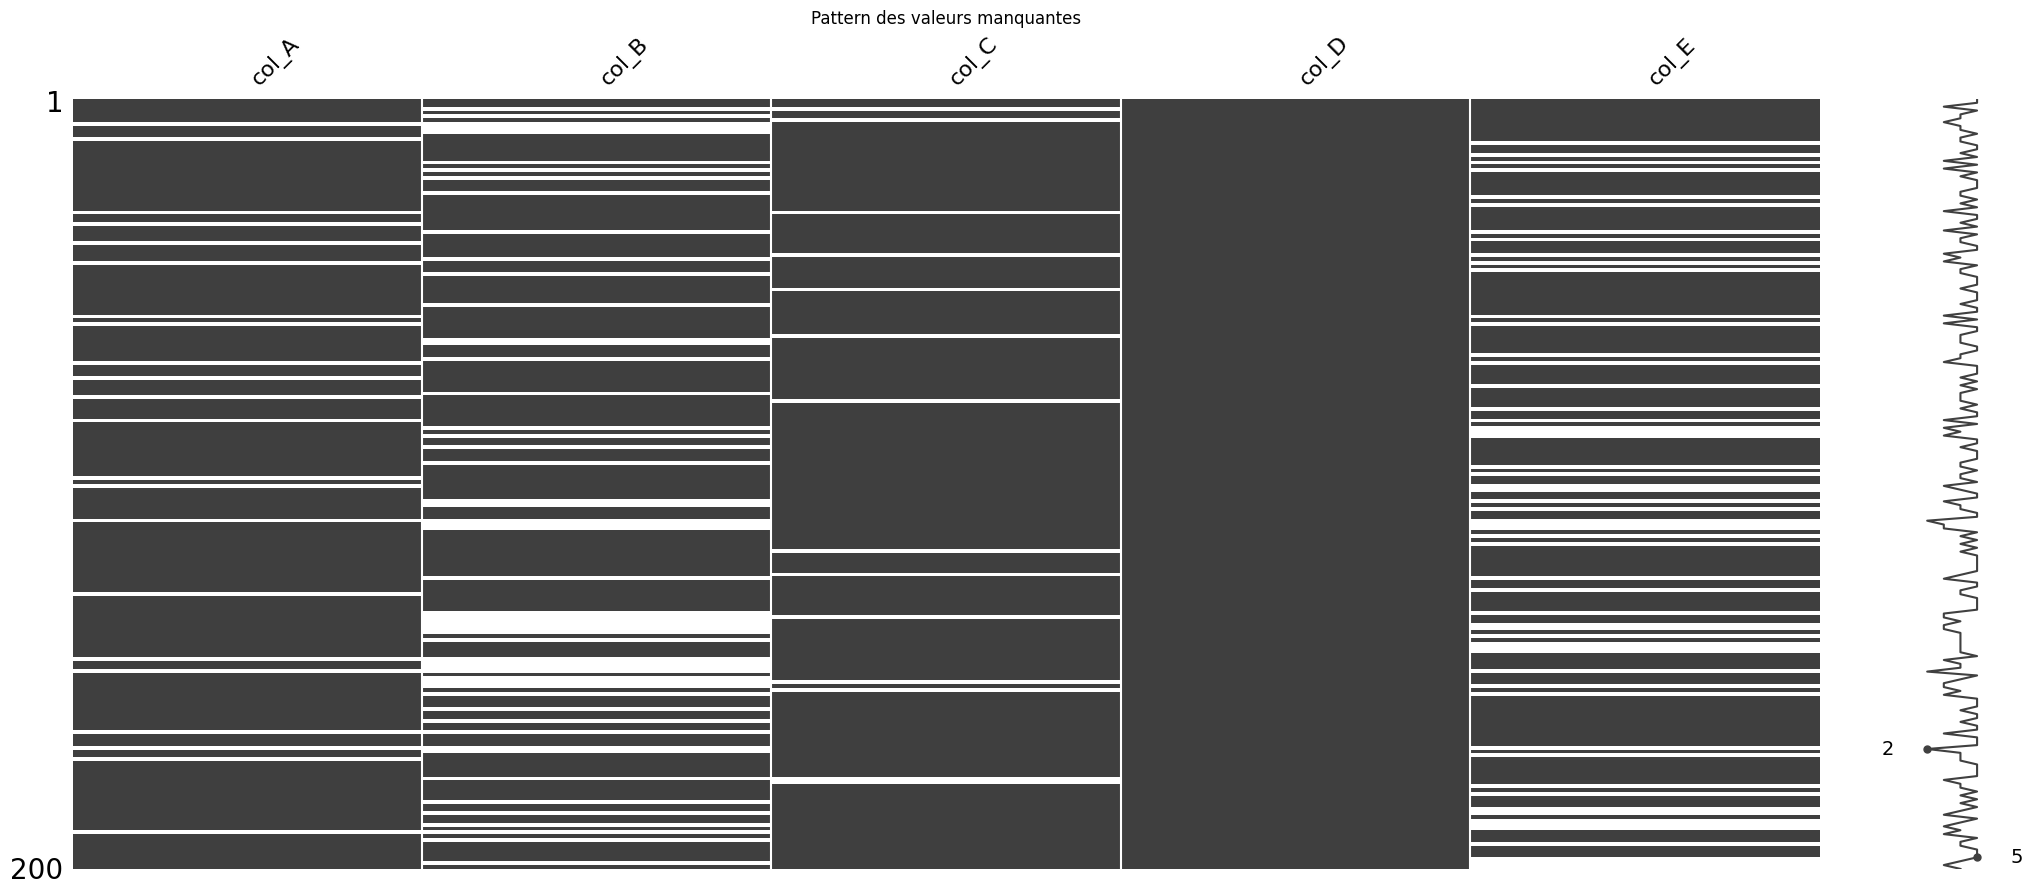

In [19]:
# Matrice de valeurs manquantes
msno.matrix(df_viz)
plt.title("Pattern des valeurs manquantes")
plt.show()

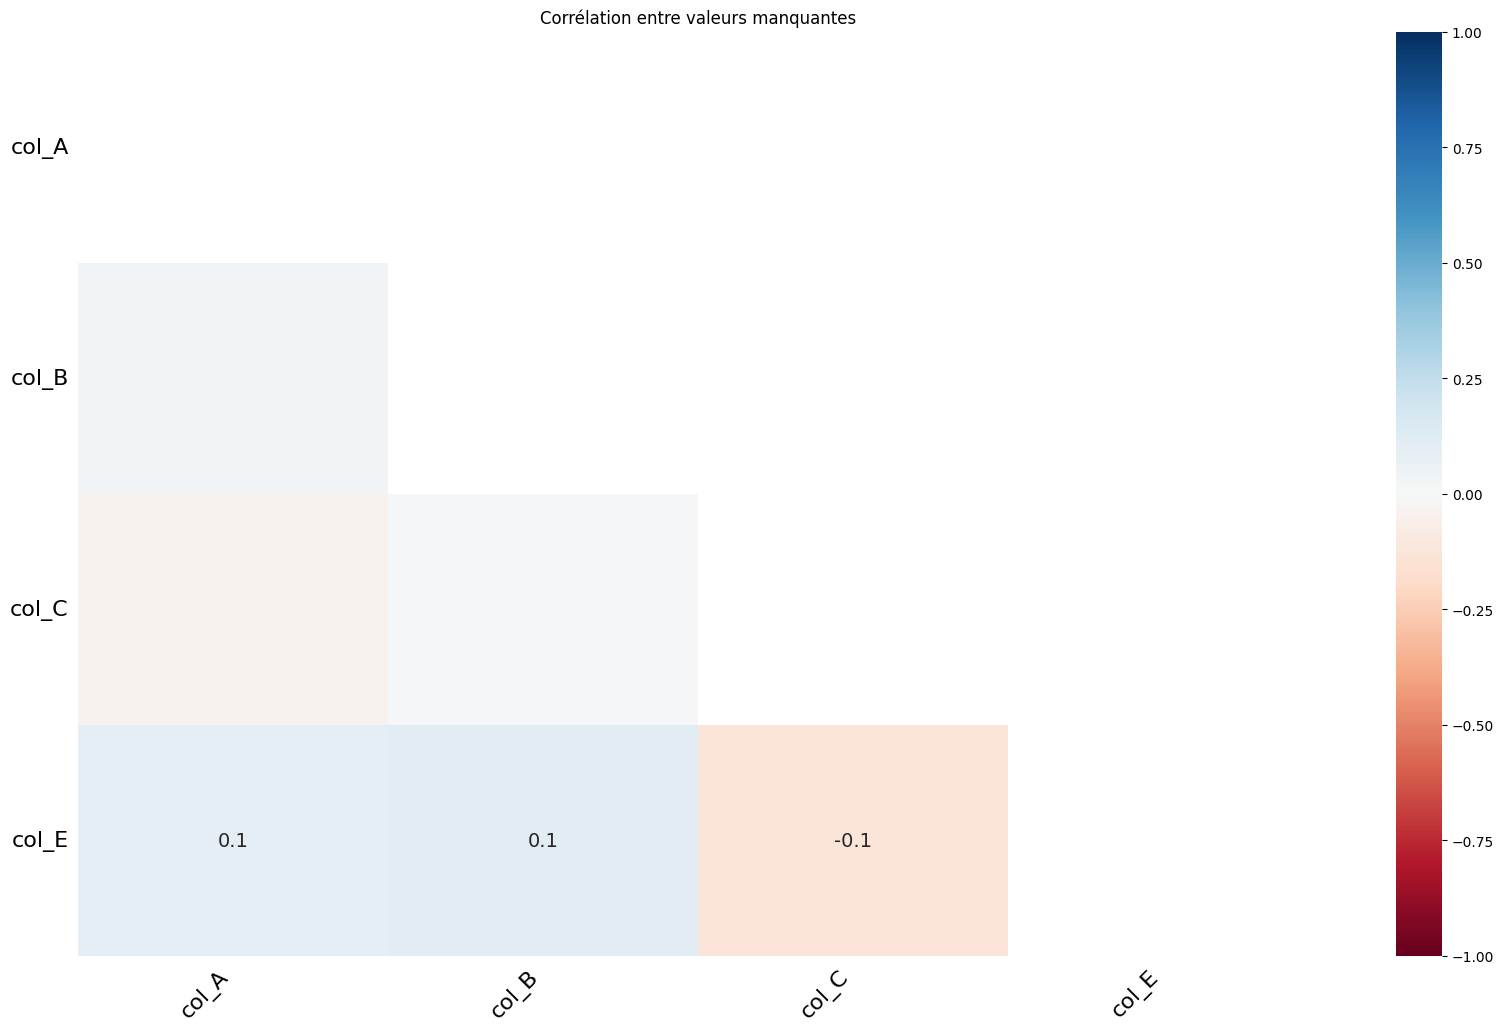

In [20]:
# Heatmap de corrélation entre missing
msno.heatmap(df_viz)
plt.title("Corrélation entre valeurs manquantes")
plt.show()

**Interprétation de la matrice :**
- Blanc = valeur manquante
- Noir = valeur présente
- Patterns verticaux = colonnes problématiques
- Patterns horizontaux = lignes problématiques

### ✍️ Exercice 4.4 : Analyse des missing (15 min)

In [13]:
import pandas as pd
import numpy as np

# Données avec patterns de missing
np.random.seed(42)
n = 1000

df_pattern = pd.DataFrame({
    'age': np.random.randint(18, 80, n),
    'revenu': np.random.randint(20000, 100000, n).astype(float),
    'education': np.random.choice(['Bac', 'Licence', 'Master', 'Doctorat'], n)
})

# Introduire des missing avec pattern
# Les jeunes (< 25 ans) ont souvent des revenus manquants
mask_jeunes = df_pattern['age'] < 25
random_mask = np.random.random(n) < 0.4
df_pattern.loc[mask_jeunes & random_mask, 'revenu'] = np.nan

# L'éducation est parfois manquante aléatoirement
random_mask_edu = np.random.random(n) < 0.05
df_pattern.loc[random_mask_edu, 'education'] = np.nan

print("DataFrame créé avec patterns de missing.")

DataFrame créé avec patterns de missing.


In [ ]:
# Analyse
print("Valeurs manquantes par colonne :")
print(df_pattern.isnull().sum())

print("\nPourcentage de revenus manquants par tranche d'âge :")
df_pattern['tranche_age'] = pd.cut(df_pattern['age'], bins=[18, 25, 35, 50, 80], labels=['18-25', '26-35', '36-50', '51+'])
print(df_pattern.head())

print(df_pattern.groupby('tranche_age')['revenu'].apply(lambda x: x.isnull().mean() * 100).round(2))

Valeurs manquantes par colonne :
age           0
revenu       42
education    45
dtype: int64

Pourcentage de revenus manquants par tranche d'âge :
   age   revenu education tranche_age
0   56  82292.0    Master         51+
1   69  43833.0       Bac         51+
2   46  24158.0       NaN       36-50
3   32  82680.0  Doctorat       26-35
4   60  40309.0    Master         51+
tranche_age
18-25    34.62
26-35     0.00
36-50     0.00
51+       0.00
Name: revenu, dtype: float64


/var/folders/01/2dhhcg55665c5vbwq1ll5qlh0000gn/T/ipykernel_70450/1813049490.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_pattern.groupby('tranche_age')['revenu'].apply(lambda x: x.isnull().mean() * 100).round(2))


In [12]:
print((df_pattern['education'].isnull().mean())*100)

4.5


In [ ]:
# Questions :
# 1. Le missing sur 'revenu' est-il MCAR, MAR ou MNAR ?
print("1. Type de missing pour 'revenu' :")
print("   → MAR (Missing At Random) - les jeunes ont plus de valeurs manquantes")

# 2. Le missing sur 'education' est-il MCAR, MAR ou MNAR ?
print("\n2. Type de missing pour 'education' :")
print("   → MCAR (Missing Completely At Random) - 5% aléatoire")

# 3. Quelle stratégie de traitement suggéreriez-vous ?
print("\n3. Stratégies suggérées :")
print("   - revenu : imputation par groupe d'âge (médiane par tranche)")
print("   - education : imputation par mode ou suppression des lignes")